# Monte Carlo Learning implementation on Frozen Lake environment

This project implements **Monte Carlo learning algorithm** to solve the **Frozen Lake** environment, a classic discrete reinforcement learning problem.

## Create frozen lake environment

Now let's create a frozen lake environment class, it should have the following features:
1. User should be able to pass the grid (2D list that contains the information about the starting point, frozen cell, holes and the goal)
2. create a helper function to create a grid based on provided parameters.
3. user should determine whethere the action is going to be deterministic or stochastic based on slipper mode.
4. state will be determine by row and column state.
5. there should be a method that takes current state and action abd based on that it should return a list of dictionary that contain the following fields `prod, next_state, reward, is_terminated`

In [45]:
import random
import numpy as np
from IPython.display import display, clear_output
import time
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

In [46]:
def generate_grid_randomly(n_rows, n_cols, n_holes=4):
    """
    Generate a random 2D Frozen Lake grid.

    The grid consists of:
    - 'F' : Frozen (safe) cells
    - 'H' : Holes (terminal failure states)
    - 'S' : Start state
    - 'G' : Goal state

    Args:
        n_rows (int): Number of rows in the grid.
        n_cols (int): Number of columns in the grid.
        n_holes (int, optional): Number of hole cells to place.
            Defaults to 4.

    Returns:
        list[list[str]]: A 2D list representing the Frozen Lake grid.
    """
    
    grid = [["F" for _ in range(n_cols)] for _ in range(n_rows)]    
    states = [(r, c) for r in range(n_rows) for c in range(n_cols)]
    
    random.shuffle(states)

    for i in range(0, n_holes):
        hole = states[i%(n_rows*n_cols)]
        r, c = hole
        
        grid[r][c] = "H"

    # start state
    r, c = states[-1]
    grid[r][c] = "S"
    
    # goal state
    r, c = states[-2]
    grid[r][c] = "G"

    return grid

In [47]:
grid = generate_grid_randomly(10, 10, n_holes=12)
grid

[['F', 'F', 'H', 'F', 'F', 'F', 'F', 'F', 'F', 'F'],
 ['F', 'F', 'F', 'F', 'F', 'F', 'F', 'F', 'F', 'F'],
 ['F', 'F', 'H', 'F', 'F', 'F', 'F', 'F', 'F', 'F'],
 ['F', 'F', 'H', 'F', 'F', 'F', 'F', 'F', 'F', 'H'],
 ['F', 'H', 'F', 'H', 'F', 'F', 'F', 'F', 'F', 'F'],
 ['F', 'F', 'F', 'F', 'F', 'F', 'H', 'F', 'F', 'F'],
 ['F', 'H', 'F', 'F', 'F', 'F', 'F', 'F', 'F', 'G'],
 ['F', 'F', 'F', 'F', 'F', 'F', 'F', 'F', 'F', 'H'],
 ['F', 'F', 'F', 'F', 'H', 'F', 'F', 'S', 'F', 'F'],
 ['F', 'H', 'F', 'F', 'H', 'F', 'F', 'F', 'F', 'F']]

Now let's create FrozenLakeEnvironment but before that we need to define some constants

In [48]:
ACTION_NAME_TO_IDX = {
    "left": 0,
    "down": 1,
    "right": 2,
    "up": 3
}
ACTION_IDX_TO_NAME = {v:k for k,v in ACTION_NAME_TO_IDX.items()}
ACTION_TO_STEP_MAPPER = {
    0: (0, -1), # left means staying in the same row (row unchanged), moving one column left from the current cell i.e -1
    1: (1, 0), # down means moving to the next row (+1 row) but staying in the same column
    2: (0, 1), # right means staying in the same row (row unchanged), moving to the subsequent right column i.e +1
    3: (-1, 0) # up means staying in the same column but moving one row up i.e -1 
}

In [91]:
class FrozenLakeEnvironment:
    def __init__(self, grid, slippery=True):
        self.grid = grid
        self.n_rows = len(grid)
        self.n_cols = len(grid[0])
        self.slippery = slippery
        self.allowed_actions = list(ACTION_NAME_TO_IDX.values())
        
        self.action_names_to_idx = ACTION_NAME_TO_IDX
        self.action_to_step_mapper = ACTION_TO_STEP_MAPPER
        
        self.start_state = self.__find("S")
        self.goal_state = self.__find("G")
        self.current_state = self.start_state
        self._display_handle = None

    def __find(self, value):
        """
        Find the position of a given value in the grid.

        Iterates through the grid and returns the first (row, column)
        coordinate where the specified value is found.
    
        Args:
            value (str): The grid cell value to search for
                (e.g., 'S', 'G', 'H', 'F').
    
        Returns:
            tuple[int, int] | None: The (row, column) position of the value
            if found; otherwise, None.
        
        """
        for r in range(self.n_rows):
            for c in range(self.n_cols):
                if self.grid[r][c] == value:
                    return (r, c)

    def __is_terminal(self, state):
        """
        check if the given state is terminating state or not (G or H)
        """
        r, c = state
        return self.grid[r][c] in ["G", "H"]

    def __move(self, state, action):
        """
        Compute the next state given a current state and an action.
    
        The agent is moved according to the action mapping. If the action
        would cause the agent to step outside the grid boundaries, the
        position is clipped to remain within valid limits.
    
        Args:
            state (tuple[int, int]): Current (row, column) position
                of the agent.
            action (int): Action index mapped to a movement direction
                via `self.action_to_step_mapper`.
    
        Returns:
            tuple[int, int]: The next (row, column) state after applying
            the action.
        """
        r, c = state
        step_r, step_c = self.action_to_step_mapper[action]
        new_r = min(max(0, r+step_r), self.n_rows -1) #make sure step is a valid one
        new_c = min(max(0, c+step_c), self.n_cols -1)
        return new_r, new_c

    def step(self, current_state, action):
        """
        The core Model-Free interface. 
        Agent provides an action, environment returns (next_state, reward, done).
        """
        if self.__is_terminal(current_state):
            return {"new_state": current_state,
                    "reward": 0,
                    "game_over": True}
                    
        actual_action = action
        if self.slippery:
            # 70% chance of success, 10% chance for each other direction
            roll = random.random()
            if roll < 0.7: # 70%
                actual_action = action
            elif roll < 0.8: # 10%
                actual_action = (action + 1) % len(self.allowed_actions)
            elif roll < 0.9: # 10%
                actual_action = (action + 2) % len(self.allowed_actions)
            else: # 10%
                actual_action = (action + 3) % len(self.allowed_actions)
        else:
            actual_action = action
        
        new_state = self.__move(current_state, actual_action)
        r, c = new_state
        cell = self.grid[r][c]
            
        if cell == "G":
            reward = 10
        elif cell == "H":
            reward = -10
        else:
            reward = -1
                
        game_over = cell in ["H", "G"]
        return {"new_state": new_state,
                "reward": reward,
                "game_over": game_over}
    
    def n_states(self):
        return self.n_rows * self.n_cols
    
    def n_actions(self):
        return len(self.allowed_actions) 

    def render(self, policy, current_state, episode_num=0, step_num=0, total_reward=0, sleep_time=0.0001):
        
        rows, cols = self.n_rows, self.n_cols
        icons = {"S": "🚀", "H": "🕳️", "G": "🏁", "F": "❄️"}
        arrows = {0: "←", 1: "↓", 2: "→", 3: "↑"}
    
        grid_display = []
        for r in range(rows):
            row_display = []
            for c in range(cols):
                tile = self.grid[r][c]
                if (r, c) == current_state:
                    content = "🤖" 
                elif tile in ["S", "F"]:
                    action = policy[r][c]
                    content = f"{icons[tile]} {arrows[action]}"
                else:
                    content = icons[tile]
                row_display.append(content)
            grid_display.append(row_display)
    
        df = pd.DataFrame(grid_display)
    
        def style_cells(val):
            style = 'width: 60px; height: 60px; text-align: center; font-size: 20px; border: 1px solid #dee2e6;'
            if "🤖" in val: return style + 'background-color: #fff3cd; border: 2px solid #ffc107;' 
            if "🏁" in val: return style + 'background-color: #d4edda;' 
            if "🕳️" in val: return style + 'background-color: #f8d7da;' 
            return style + 'background-color: #89cfef;'
    
        # Generate the styled HTML for the table
        styled_html = df.style.map(style_cells).to_html()
        
        # Combine Header and Table into one HTML string
        header_html = f"<div style='font-family: sans-serif; margin-bottom: 10px;'>" \
                      f"<b>Episode:</b> {episode_num} | <b>Step:</b> {step_num} | <b>Score:</b> {total_reward}</div>"
        
        full_output = HTML(header_html + styled_html)
    
        if self._display_handle is None:
            # First time: display the combined HTML and capture handle
            self._display_handle = display(full_output, display_id=True)
        else:
            # Subsequent steps: update the same handle with the new combined HTML
            self._display_handle.update(full_output)
        
        # time.sleep(sleep_time)

## Testing the environment

In [92]:
# let's define grid (we can we the dynamic grid generator too)
lake_grid = [["F", "S", "F"],
             ["F", "H", "F"],
             ["F", "F", "G"]]

In [93]:
frozen_lake = FrozenLakeEnvironment(grid=lake_grid,
                                    slippery=True)

In [94]:
frozen_lake.current_state

(0, 1)

In the above grid the position of "S" state is (0, 1), so current_state is giving the expected state coordinate.

In [95]:
# let's test the move method, if we are at (0, 0) state and try to move up, we should be at the same state
current_state = (0, 0)
action_index = frozen_lake.action_names_to_idx["up"]
frozen_lake._FrozenLakeEnvironment__move(current_state, action_index)

(0, 0)

In [96]:
# let's test the move method, if we are at (0, 0) state and try to move right, we should reach to the (0, 1) state
current_state = (0, 0)
action_index = frozen_lake.action_names_to_idx["right"]
frozen_lake._FrozenLakeEnvironment__move(current_state, action_index)

(0, 1)

`__move()` method is showing expected behaviour.

In [97]:
# Now let's test the transition prob, if we are at the Goal "G" i.e (3,3) and try to move, we are supposed to stuck to that state
frozen_lake.step((2, 2), action_index)

{'new_state': (2, 2), 'reward': 0, 'game_over': True}

In [98]:
# Now let's test the transition prob for near goal state
frozen_lake.step((1, 2), action_index)

{'new_state': (2, 2), 'reward': 10, 'game_over': True}

So far we have build a frozen lake environment if anything needs to add later, we will do that for for now we are good to go stright to the policy iteration algorithm implementation.

# Monte Carlo Learning

Monte Carlo (MC) learning is a class of model-free reinforcement learning methods that learn value functions from complete episodes of experience, using sampled returns instead of a model of the environment.

**Unlike Dynamic Programming:**
- ❌ No transition model 𝑃(𝑠′∣𝑠,𝑎)
- ❌ No reward model 𝑅(𝑠,𝑎)
- ✅ Learns directly from experience

## The simplest Monte-carlo-based RL algorithm 
- The key to understand the algorithm is to understand <span style="color:green"> how to convert the policy iteration algorithm to be model free </span>
- Policy iteration has two steps in each iteration:
    - policy evaluation:
        - For a given policy ${\pi_k}$, we calculate state value ${v_{\pi_k}}$ by solving the Bellman's equation ${v_{\pi_k} = r_{\pi_k} + \gamma P_{\pi_k} v_{\pi_k} }$
    - policy improvement:
        - once ${v_{\pi_k}}$ is know, we improve the policy ${\pi_{k+1} = argmax_{\pi} (r_\pi + \gamma P_\pi v_{\pi_k})}$

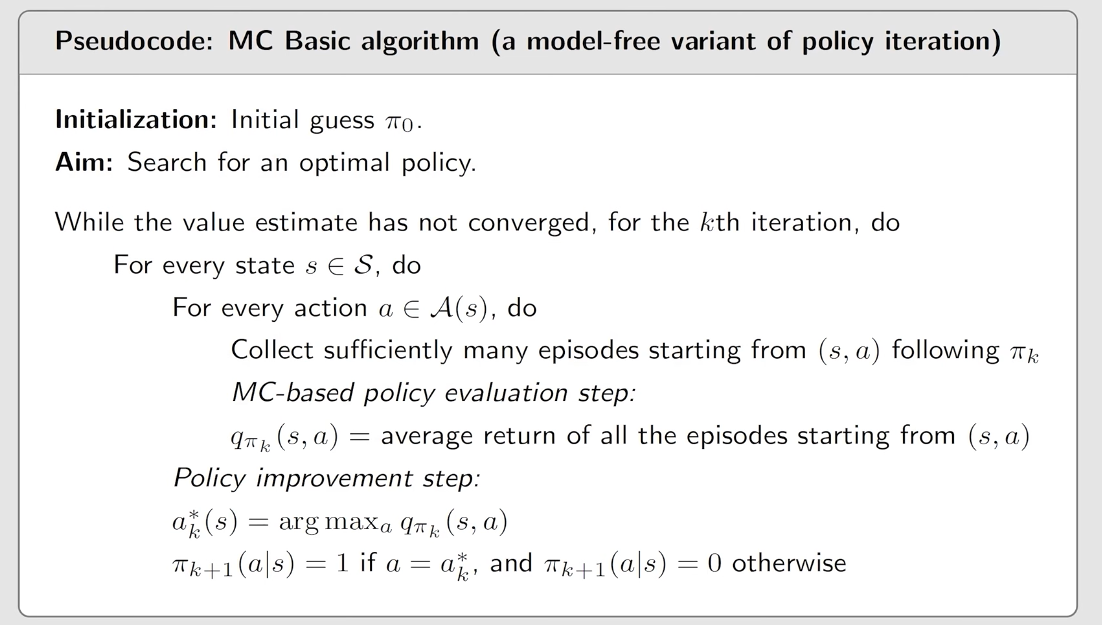

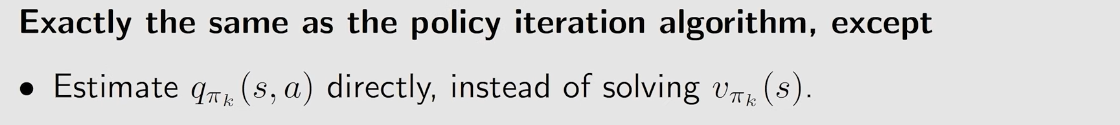

# Keypoints:
- MC basic is a variant of policy iteration algorithm
- The model-free algorithm are build up based on model-based one
- MC basic is useful to reveal the core idea of Monte-Carlo-based model-free RL, but not practical due to low efficiency.
- Why does MC basic estimates action values instead of state values?
  - because state values cannot be used to improve policies directly. When models are not available we should directly estimate action values.
- Since policy iteration is convergent, the convergence of MC basic is also guaranteed, given sufficient episodes. 

In [99]:
def run_episode(env, policy, current_state, action, gamma=0.99, max_steps=1000, episode_num=0, verbose=0):
    """
    verbose : 
      - 0 : None 
      - 1 : CLI
      - 2 : GUI  
    """
    
    total_reward = 0
    for step in range(max_steps):        
        out = env.step(current_state, action)
        next_state = out["new_state"]
        reward = out["reward"]
        game_over = out["game_over"]
        
        total_reward += gamma**step * reward

        current_state = next_state
        action = policy[current_state[0]][current_state[1]]

        if verbose == 1:
            print(f"step {step}: current_state: {current_state} -> Action: {action} -> Reward: {reward} -> Next state: {next_state}")
        elif verbose == 2:
            env.render(policy, current_state, episode_num, step, total_reward)
            
        if game_over:
            break    
    return total_reward

In [100]:
frozen_lake.grid

[['F', 'S', 'F'], ['F', 'H', 'F'], ['F', 'F', 'G']]

In [101]:
policy = np.zeros((frozen_lake.n_rows, frozen_lake.n_cols))

In [102]:
run_episode(frozen_lake, policy, (0, 0), 2, episode_num=0, verbose=2)

,0,1,2
0,❄️ ←,🚀 ←,❄️ ←
1,❄️ ←,🕳️,❄️ ←
2,❄️ ←,🤖,🏁


-26.413106557335126

In [61]:
def state_2d_to_1d(state_coords, n_cols):
    """
    Converts (row, col) to a single integer index.
    
    Args:
        state_coords (tuple): (row, col)
        n_cols (int): Number of columns in the grid
    """
    r, c = state_coords
    return r * n_cols + c

def state_1d_to_2d(state_index, n_cols):
    """
    Converts a single integer index back to (row, col).
    
    Args:
        state_index (int): The 1D state representation
        n_cols (int): Number of columns in the grid
    """
    r = state_index // n_cols
    c = state_index % n_cols
    return (r, c)

In [62]:
[state_2d_to_1d((r, c), frozen_lake.n_cols)
 for r in range(frozen_lake.n_rows)
 for c in range(frozen_lake.n_cols)]

[0, 1, 2, 3, 4, 5, 6, 7, 8]

In [63]:
[state_1d_to_2d(state, frozen_lake.n_cols)
  for state in range(15)]

[(0, 0),
 (0, 1),
 (0, 2),
 (1, 0),
 (1, 1),
 (1, 2),
 (2, 0),
 (2, 1),
 (2, 2),
 (3, 0),
 (3, 1),
 (3, 2),
 (4, 0),
 (4, 1),
 (4, 2)]

In [64]:
def policy_evaluation(env, policy, Q, num_episode=100):
    for r in range(env.n_rows):
        for c in range(env.n_cols):
            for a in env.allowed_actions:
                current_state = (r, c)
                total_G = 0
                for e in range(num_episode):
                    total_G += run_episode(env, policy, current_state, a, episode_num=e, max_steps=1000, verbose=2)
                avg_G = total_G / num_episode
                Q[state_2d_to_1d(current_state, env.n_cols)][a] = avg_G
    return Q

In [65]:
def policy_improvement(env, Q, gamma=0.99):
    new_policy = np.zeros((env.n_rows, env.n_cols), dtype=np.int8)
    for r in range(env.n_rows):
        for c in range(env.n_cols):
            
            if env.grid[r][c] in ["H", "G"]:
                continue
            
            # state = (r, c)
            action_values = []
            for action in env.allowed_actions:
                state = (r, c)
                state = state_2d_to_1d(state, env.n_cols)
                q = Q[state][action]
                action_values.append(q)
                
            # pick a greedy action with a highest
            new_policy[r][c] = np.argmax(action_values).item()
    return new_policy

In [66]:
def mc_basic_run(env):
    policy_history = []
    Q_history = []
    n_rows = env.n_rows
    n_cols = env.n_cols
    policy = np.zeros((n_rows, n_cols), dtype=np.int8)
    Q = np.zeros((env.n_states(), env.n_actions()), dtype=np.float32)
    while True:
        Q = policy_evaluation(env, policy, Q)
        new_policy = policy_improvement(env, Q)
        
        if np.array_equal(policy, new_policy):
            break
    
        policy = new_policy
        policy_history.append(policy)
        Q_history.append(Q)
        
    return policy, Q, policy_history, Q_history

In [67]:
frozen_lake = FrozenLakeEnvironment(grid=lake_grid,
                                    slippery=True)

In [ ]:
policy, Q, policy_history, V_history = mc_basic_run(frozen_lake)

,0,1,2
0,❄️ →,🤖,❄️ ↓
1,❄️ ↓,🕳️,❄️ ↓
2,❄️ →,❄️ →,🏁


IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [70]:
policy

array([[2, 2, 1],
       [1, 0, 1],
       [2, 2, 0]], dtype=int8)

# Render policy
Let's create a rendering function to visualize the policy clearly.

In [71]:
import matplotlib.pyplot as plt

In [72]:
ARROWS = {
    0: "←",
    1: "↓",
    2: "→",
    3: "↑"
}

In [73]:
import pandas as pd
from IPython.display import display

def render_policy_and_value(env, policy, V=None):
    """
    Render the policy and optionally the state-value function in a 
    visually appealing grid format using emojis and arrows.

    Args:
        env: Frozen Lake environment object with `grid`, `n_rows`, `n_cols`
        policy: 2D array of actions for each state
        V: 2D array of state values (optional)
    """
    rows, cols = env.n_rows, env.n_cols
    
    # Icons and arrows
    icons = {"S": "🚀", "H": "🕳️", "G": "🏁", "F": ""}
    arrows = {0: "←", 1: "↓", 2: "→", 3: "↑"}

    # --- Policy Display ---
    grid_policy = []
    for r in range(rows):
        row_display = []
        for c in range(cols):
            tile = env.grid[r][c]
            if tile in ["S", "F"]:
                action = policy[r][c]
                content = f"{icons[tile]} {arrows[action]}"
            else:
                content = icons[tile]
            row_display.append(content)
        grid_policy.append(row_display)

    df_policy = pd.DataFrame(grid_policy)
    
    # --- Value Function Display ---
    if V is not None:
        grid_value = []
        for r in range(rows):
            row_display = []
            for c in range(cols):
                val = V[r][c]
                row_display.append(f"{val:.2f}")
            grid_value.append(row_display)
        df_value = pd.DataFrame(grid_value)

    # --- Styling function ---
    def style_cells(val):
        style = 'width: 60px; height: 60px; text-align: center; font-size: 20px; border: 1px solid #dee2e6;'
        if "🏁" in val: return style + 'background-color: #d4edda;' # Green
        if "🕳️" in val: return style + 'background-color: #f8d7da;' # Red
        if "🚀" in val: return style + 'background-color: #cce5ff;' # Blue
        return style + 'background-color: #89cfef;'  # Frozen tiles

    # --- Render ---
    print("Policy:")
    display(df_policy.style.map(style_cells))
    
    if V is not None:
        print("action-Value Function:")
        display(df_value.style.set_properties(**{
            'width': '60px', 
            'height': '60px', 
            'text-align': 'center', 
            'font-size': '16px',
            'border': '1px solid #dee2e6'
        }))


In [74]:
render_policy_and_value(frozen_lake, policy, Q)

Policy:


,0,1,2
0,→,🚀 →,↓
1,↓,🕳️,↓
2,→,→,🏁


action-Value Function:


,0,1,2
0,1.04,-1.30,1.21
1,-0.64,-5.75,3.02
2,3.67,7.18,2.89


# Animate policy and state value history

In [103]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np
from IPython.display import HTML

In [104]:
def animate_policy_value_video(env, policy_history, V_history=None, interval=500):
    """
    Animate the evolution of policy and state-value function like a video.

    Args:
        env: Frozen Lake environment with `grid`, `n_rows`, `n_cols`
        policy_history: List of 2D arrays of actions
        V_history: Optional list of 2D arrays of state values
        interval: Time between frames in milliseconds
    """
    rows, cols = env.n_rows, env.n_cols
    arrows = {0: '←', 1: '↓', 2: '→', 3: '↑'}
    
    fig, ax = plt.subplots(figsize=(cols//2, rows//2))
    
    def update(frame):
        ax.clear()
        ax.set_xticks(np.arange(cols+1)-0.5, minor=False)
        ax.set_yticks(np.arange(rows+1)-0.5, minor=False)
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        ax.grid(True)
        ax.invert_yaxis()

        policy = policy_history[frame]
        if V_history is not None:
            V = V_history[frame]
            # Plot heatmap
            im = ax.imshow(V, cmap='Blues', alpha=0.6)
            for (r, c), val in np.ndenumerate(V):
                ax.text(c, r, f"{val:.1f}", ha='center', va='center', fontsize=15)
        else:
            im = None

        # Overlay policy arrows
        for r in range(rows):
            for c in range(cols):
                tile = env.grid[r][c]
                if tile in ['H', 'G', 'S']:
                    continue
                action = policy[r][c]
                ax.text(c, r, arrows[action], ha='center', va='center', fontsize=15, color='red')

        # Overlay start, goal, hole
        for r in range(rows):
            for c in range(cols):
                tile = env.grid[r][c]
                if tile == 'S':
                    ax.text(c, r, 'S', ha='center', va='center', fontsize=15)
                elif tile == 'G':
                    ax.text(c, r, 'G', ha='center', va='center', fontsize=15)
                elif tile == 'H':
                    ax.text(c, r, 'H', ha='center', va='center', fontsize=15)

        ax.set_title(f"Iteration {frame+1}")

    ani = animation.FuncAnimation(fig, update, frames=len(policy_history), interval=interval)
    plt.close(fig)  # Prevent double display in notebooks
    return ani


In [105]:
ani = animate_policy_value_video(frozen_lake, policy_history)
HTML(ani.to_jshtml())

# Let Play with different grid setup

In [108]:
grid = generate_grid_randomly(2, 3, n_holes=1)
grid

[['G', 'F', 'F'], ['H', 'F', 'S']]

In [ ]:
frozen_lake = FrozenLakeEnvironment(grid=grid,
                                    slippery=True)

policy, Q, policy_history, V_history = mc_basic_run(frozen_lake)

,0,1,2
0,🏁,🤖,❄️ →
1,🕳️,❄️ ↑,🚀 ↑


In [112]:
len(policy_history)

3

In [113]:
ani = animate_policy_value_video(frozen_lake, policy_history)
HTML(ani.to_jshtml())